# 🎙️ Cross-Lingual Emotion Voice Conversion Style Transfer Demo
### *Conditioned Speech Synthesis using Tacotron2-VAE and WaveGlow (CPU)*

This notebook demonstrates how to load a trained **Tacotron2-VAE** acoustic model and a pre-trained **WaveGlow** vocoder on **CPU** to perform style transfer.

Given a reference audio file from the Portuguese corpus (`tts-portuguese-Corpora`), the VAE extracts its style/prosody representation. This latent style is then injected into the text representation of the target sentence **"O astro e marrom"** to generate a style-transferred mel-spectrogram, which is subsequently inverted into a high-fidelity waveform by WaveGlow.

### 1. Setup Environment and Imports

In [1]:
import os
import sys
import json
import csv
import glob
from pathlib import Path

# Set working directory to project root
os.chdir(Path.cwd().parent)
ROOT_DIR = Path.cwd()

# Append source directories to path
sys.path.insert(0, str(ROOT_DIR / "src"))
sys.path.insert(0, str(ROOT_DIR / "src" / "models" / "tacotron2_vae"))
sys.path.insert(0, str(ROOT_DIR / "src" / "models" / "waveglow"))
sys.path.insert(0, str(ROOT_DIR / "src" / "training" / "training-tacotron2-vae"))
sys.path.insert(0, str(ROOT_DIR / "src" / "data" / "loader_vae_tacotron"))

import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

from layers import TacotronSTFT
from glow import WaveGlow
from hparams import Tacotron2VAEHparams
from model import load_tacotron2_vae_model
from text_processing import TextProcessor

device = torch.device("cpu")
print(f"Using device: {device}")

/home/richard/project/ml2_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


### 2. Load Configurations

In [2]:
# 1. Load Tacotron VAE hyperparameters
hparams_path = Path("experiments/tacotron2-vae/tts_ptbr_fonetico_v4/hparams.json")
with open(hparams_path, "r") as f:
    hparams_data = json.load(f)
hparams = Tacotron2VAEHparams.from_dict(hparams_data)

# 2. Load symbols vocabulary
symbols_path = Path("experiments/tacotron2-vae/tts_ptbr_fonetico_v4/symbols.json")
with open(symbols_path, "r") as f:
    symbols_data = json.load(f)
symbols = symbols_data["symbols"]

# 3. Initialize TextProcessor
text_processor = TextProcessor(symbols=symbols)
print(f"Loaded {len(symbols)} symbols. Vocabulary initialized successfully.")

Loaded 198 symbols. Vocabulary initialized successfully.


### 3. Load and Process Reference Audio
We load a raw audio file from the Portuguese corpus (`tts-portuguese-Corpora`), resample it to 22050 Hz (if it's not already at that rate), and extract its Mel-spectrogram using `TacotronSTFT`.

In [3]:
# Load reference path from metadata CSV or fallback
metadata_csv = Path("data/processed/tts-portuguese-Corpora/mels_metadata.csv")
ref_audio_path = "data/raw/tts-portuguese-Corpora/TTS-Portuguese-Corpus/wavs/sample-0.wav"

if metadata_csv.exists():
    with open(metadata_csv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        row = next(reader)
        ref_audio_path = row.get("source_wav", ref_audio_path)

print(f"Loading reference audio from: {ref_audio_path}")
waveform, sr = torchaudio.load(ref_audio_path)
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

# Resample to 22050 Hz if needed
if sr != 22050:
    print(f"Resampling from {sr}Hz to 22050Hz...")
    resample = T.Resample(orig_freq=sr, new_freq=22050)
    waveform = resample(waveform)
    sr = 22050

# Compute Mel-spectrogram via TacotronSTFT engine
stft = TacotronSTFT(
    filter_length=hparams.filter_length,
    hop_length=hparams.hop_length,
    win_length=hparams.win_length,
    n_mel_channels=hparams.n_mel_channels,
    sampling_rate=hparams.sampling_rate,
    mel_fmin=hparams.mel_fmin,
    mel_fmax=hparams.mel_fmax
)

ref_mel = stft.mel_spectrogram(waveform).to(device) # shape: (1, 80, T_mel)
print(f"Reference waveform shape: {waveform.shape}")
print(f"Reference mel-spectrogram shape: {ref_mel.shape}")

Loading reference audio from: /home/richard/project/ml2_final_project/data/raw/tts-portuguese-Corpora/TTS-Portuguese-Corpus/wavs/sample-0.wav


Resampling from 48000Hz to 22050Hz...


Reference waveform shape: torch.Size([1, 93272])
Reference mel-spectrogram shape: torch.Size([1, 80, 365])


### 4. Load Models on CPU

In [4]:
# Discover the latest Tacotron2-VAE checkpoint
checkpoint_dir = Path("experiments/tacotron2-vae")
checkpoint_files = sorted(
    glob.glob(str(checkpoint_dir / "checkpoints" / "epoch_*")) +
    glob.glob(str(checkpoint_dir / "checkpoints" / "checkpoint_*")) +
    glob.glob(str(checkpoint_dir / "attempt_*" / "checkpoints" / "epoch_*")) +
    glob.glob(str(checkpoint_dir / "attempt_*" / "checkpoints" / "checkpoint_*"))
)

if not checkpoint_files:
    raise FileNotFoundError("No Tacotron VAE checkpoints found in experiments/tacotron2-vae/.")

latest_checkpoint = "experiments/tacotron2-vae/tts_ptbr_fonetico_v4/checkpoints/epoch_42000"
print(f"Loading Tacotron VAE checkpoint: {latest_checkpoint}")

tacotron_model = load_tacotron2_vae_model(hparams, device=device)
checkpoint_data = torch.load(latest_checkpoint, map_location="cpu", weights_only=False)
state_dict = checkpoint_data.get("state_dict", checkpoint_data)

# Clean module prefix if DDP was used
from collections import OrderedDict
cleaned_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith("module.") else k
    cleaned_state_dict[name] = v

tacotron_model.load_state_dict(cleaned_state_dict)
tacotron_model.eval()

Loading Tacotron VAE checkpoint: experiments/tacotron2-vae/tts_ptbr_fonetico_v4/checkpoints/epoch_42000


Tacotron2(
  (transcript_embedding): Embedding(198, 512)
  (encoder): Encoder(
    (convolutions): ModuleList(
      (0-2): 3 x Sequential(
        (0): ConvNorm(
          (conv): Conv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
        )
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (lstm): LSTM(512, 256, batch_first=True, bidirectional=True)
  )
  (decoder): Decoder(
    (prenet): Prenet(
      (layers): ModuleList(
        (0): LinearNorm(
          (linear_layer): Linear(in_features=80, out_features=256, bias=False)
        )
        (1): LinearNorm(
          (linear_layer): Linear(in_features=256, out_features=256, bias=False)
        )
      )
    )
    (attention_rnn): LSTMCell(768, 1024)
    (attention_layer): Attention(
      (query_layer): LinearNorm(
        (linear_layer): Linear(in_features=1024, out_features=128, bias=False)
      )
      (memory_layer): LinearNorm(
        (linear

In [5]:
# Load WaveGlow Vocoder on CPU
waveglow_path = "local_weight_models/waveglow/nvidia_waveglowpyt_fp32_20190427"
print(f"Loading WaveGlow vocoder from: {waveglow_path}")

# Configuration matching Nvidia pre-trained checkpoint shape
config = {
    "waveglow_config": {
        "n_mel_channels": 80,
        "n_flows": 12,
        "n_group": 8,
        "n_early_every": 4,
        "n_early_size": 2,
        "WN_config": {
            "n_layers": 8,
            "n_channels": 512,
            "kernel_size": 3
        }
    }
}

waveglow_model = WaveGlow(**config["waveglow_config"]).to(device)
wg_checkpoint = torch.load(waveglow_path, map_location="cpu", weights_only=False)
wg_state_dict = wg_checkpoint.get("state_dict", wg_checkpoint)

cleaned_wg_sd = OrderedDict()
for k, v in wg_state_dict.items():
    name = k[7:] if k.startswith("module.") else k
    cleaned_wg_sd[name] = v

waveglow_model.load_state_dict(cleaned_wg_sd)
waveglow_inference_model = WaveGlow.remove_weightnorm(waveglow_model)
waveglow_inference_model.eval()
print("WaveGlow model loaded successfully on CPU.")

Loading WaveGlow vocoder from: local_weight_models/waveglow/nvidia_waveglowpyt_fp32_20190427


/home/richard/project/ml2_final_project/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


WaveGlow model loaded successfully on CPU.


### 5. Perform Style Transfer
We process the sentence "O astro e marrom", inject the style representation from the reference audio, and generate the final speech waveform.

In [6]:
target_text = "O sol está brilhando muito forte hoje na cidade de São Paulo."
print(f"Target sentence: '{target_text}'")

# Tokenize text
text_sequence = text_processor.text_to_sequence(target_text)
text_tensor = torch.LongTensor(text_sequence).unsqueeze(0).to(device) # shape: (1, T_text)

with torch.no_grad():
    # 1. Encode text
    embedded_inputs = tacotron_model.transcript_embedding(text_tensor).transpose(1, 2)
    transcript_outputs = tacotron_model.encoder.inference(embedded_inputs)

    # 2. Extract style from reference mel-spectrogram
    latent_vector, _, _, _ = tacotron_model.vae_gst(ref_mel)

    # 3. Inject style into text representations
    latent_vector = latent_vector.unsqueeze(1).expand_as(transcript_outputs)
    encoder_outputs = transcript_outputs + latent_vector

    # 4. Decode style-conditioned representations to mel-spectrogram
    mel_outputs, _, alignments = tacotron_model.decoder.inference(encoder_outputs)

    # 5. Postnet refinement
    mel_outputs_postnet = tacotron_model.postnet(mel_outputs)
    synthesized_mel = mel_outputs + mel_outputs_postnet

    # 6. Vocode synthesized mel-spectrogram to audio waveform via WaveGlow
    synthesized_audio = waveglow_inference_model.infer(synthesized_mel, sigma=0.6)

print(f"Synthesized audio shape: {synthesized_audio.shape}")

Target sentence: 'O sol está brilhando muito forte hoje na cidade de São Paulo.'


Warning! Reached max decoder steps


Synthesized audio shape: torch.Size([1, 256000])


### 6. Listen and Visualize

In [7]:
print("Reference Audio:")
display(Audio(waveform[0].numpy(), rate=22050))

print("Synthesized Style-Transferred Audio:")
display(Audio(synthesized_audio[0].data.cpu().numpy(), rate=22050))
import torchaudio
torchaudio.save("style_transfer_output.wav", synthesized_audio.cpu(), 22050)
print("Saved output to style_transfer_output.wav")


Reference Audio:


Synthesized Style-Transferred Audio:


Saved output to style_transfer_output.wav


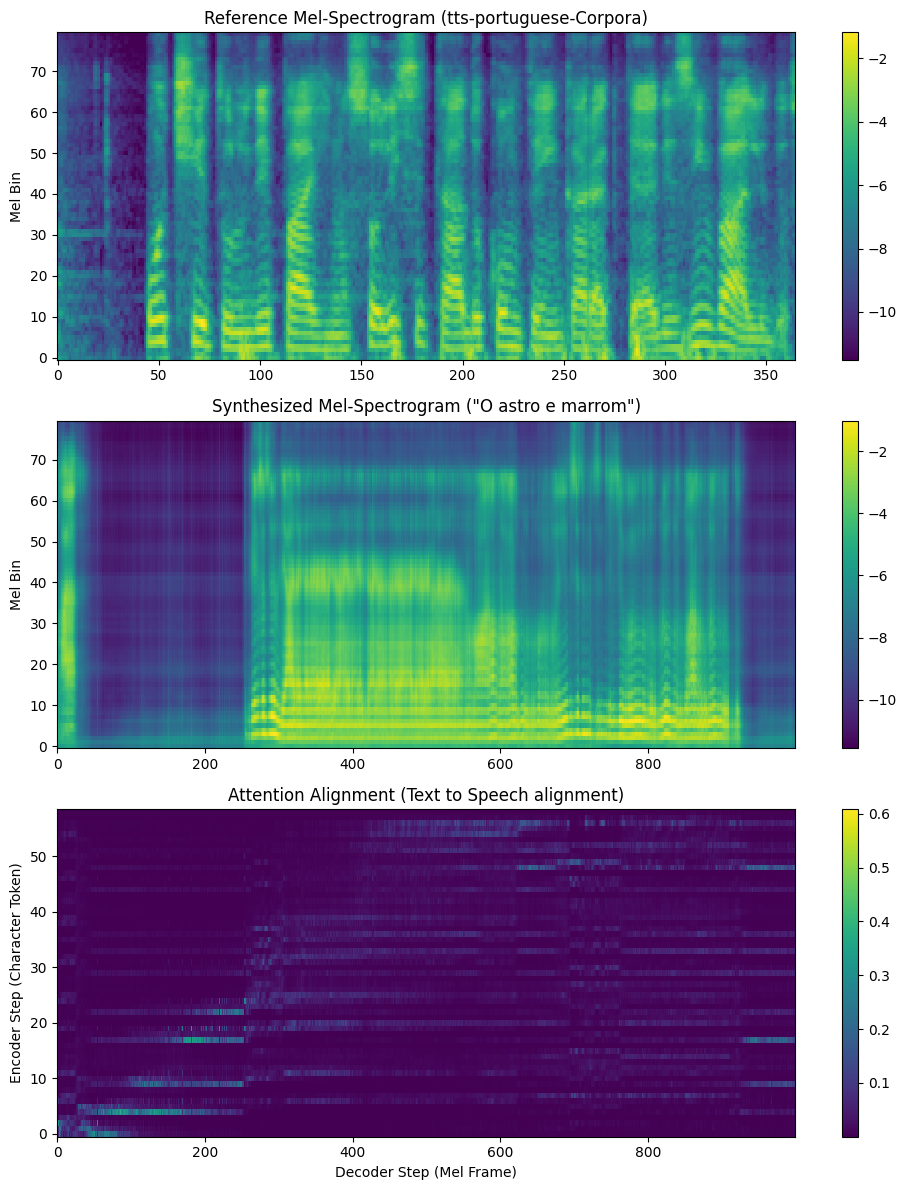

In [8]:
# Plotting the results
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# 1. Reference Mel-Spectrogram
im1 = axes[0].imshow(ref_mel[0].cpu().numpy(), origin="lower", aspect="auto", interpolation="nearest")
axes[0].set_title("Reference Mel-Spectrogram (tts-portuguese-Corpora)")
axes[0].set_ylabel("Mel Bin")
fig.colorbar(im1, ax=axes[0])

# 2. Synthesized Mel-Spectrogram
im2 = axes[1].imshow(synthesized_mel[0].cpu().numpy(), origin="lower", aspect="auto", interpolation="nearest")
axes[1].set_title("Synthesized Mel-Spectrogram (\"O astro e marrom\")")
axes[1].set_ylabel("Mel Bin")
fig.colorbar(im2, ax=axes[1])

# 3. Attention Alignment
im3 = axes[2].imshow(alignments[0].cpu().numpy().T, origin="lower", aspect="auto", interpolation="nearest")
axes[2].set_title("Attention Alignment (Text to Speech alignment)")
axes[2].set_xlabel("Decoder Step (Mel Frame)")
axes[2].set_ylabel("Encoder Step (Character Token)")
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()